This notebook is for model1 training (random(first) 5 households are used for training and two(seen and unseen households) types of testing where we use autoregressive rolling based testing for 30 day forecast.)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv('/content/drive/My Drive/uk_data_clean.csv')

In [4]:
pivoted = df.pivot(index='datetime', columns='id', values='target')

def dtarg(x):
  return(pd.to_datetime(x,format='%Y-%m-%d %H:%M:%S'))

pivoted.index = pivoted.index.map(dtarg)

np.random.seed(216)

testcols = np.random.choice(pivoted.columns, size=int((len(pivoted.columns)*.2)//1), replace=False, p=None)
traincols = [x for x in pivoted.columns if x not in testcols]

energy = pivoted[traincols]
energy_testing_set = pivoted[testcols]

In [5]:
energy_testing_set.columns

Index(['uk_MAC003375', 'uk_MAC004019', 'uk_MAC003901', 'uk_MAC002320',
       'uk_MAC002547', 'uk_MAC001857', 'uk_MAC003796', 'uk_MAC003081',
       'uk_MAC000714', 'uk_MAC003958',
       ...
       'uk_MAC000742', 'uk_MAC002753', 'uk_MAC003397', 'uk_MAC001665',
       'uk_MAC004449', 'uk_MAC003082', 'uk_MAC005341', 'uk_MAC005162',
       'uk_MAC001869', 'uk_MAC000769'],
      dtype='object', name='id', length=183)

In [6]:
energy.columns

Index(['uk_MAC000010', 'uk_MAC000018', 'uk_MAC000019', 'uk_MAC000027',
       'uk_MAC000034', 'uk_MAC000048', 'uk_MAC000049', 'uk_MAC000057',
       'uk_MAC000075', 'uk_MAC000091',
       ...
       'uk_MAC005475', 'uk_MAC005480', 'uk_MAC005508', 'uk_MAC005525',
       'uk_MAC005526', 'uk_MAC005527', 'uk_MAC005539', 'uk_MAC005540',
       'uk_MAC005545', 'uk_MAC005549'],
      dtype='object', name='id', length=736)

In [7]:
pivot = energy.copy()

In [8]:
pivot = pivot.iloc[:,:5]

In [9]:
pivot

id,uk_MAC000010,uk_MAC000018,uk_MAC000019,uk_MAC000027,uk_MAC000034
datetime,,,,,
2012-11-01 00:00:00,0.863,0.335,0.043,0.177,0.584
2012-11-01 00:30:00,0.287,0.500,0.069,0.185,0.609
2012-11-01 01:00:00,0.231,0.675,0.092,0.157,0.164
2012-11-01 01:30:00,0.177,0.554,0.088,0.179,0.102
2012-11-01 02:00:00,0.231,0.556,0.095,0.104,0.129
...,...,...,...,...,...
2013-11-30 21:30:00,1.059,0.148,0.216,0.302,0.296
2013-11-30 22:00:00,0.833,0.139,0.192,0.258,0.264
2013-11-30 22:30:00,0.439,0.140,0.203,0.258,0.244


In [10]:
# Time features
tf = pd.DataFrame(index=pivot.index)
tf['hour'] = pivot.index.hour + pivot.index.minute / 60
tf['dow'] = pivot.index.dayofweek
tf['month'] = pivot.index.month

# Cyclical encoding, this way model understands how close 23:30 and 00:30 are...., we could possible have remove month versions.
import numpy as np
tf['hour_sin'] = np.sin(2 * np.pi * tf['hour'] / 24)
tf['hour_cos'] = np.cos(2 * np.pi * tf['hour'] / 24)
tf['dow_sin'] = np.sin(2 * np.pi * tf['dow'] / 7)
tf['dow_cos'] = np.cos(2 * np.pi * tf['dow'] / 7)
tf['month_sin'] = np.sin(2 * np.pi * tf['month'] / 12)
tf['month_cos'] = np.cos(2 * np.pi * tf['month'] / 12)

time_features = tf[['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']].values

In [11]:
pivot.shape[0]

18960

In [12]:
input_window = 7 * 48       # 336
forecast_horizon = 1 * 48   # 48

total_samples = pivot.shape[0] - input_window - forecast_horizon

# Create raw data splits before scaling
split1 = int(0.7 * total_samples)
split2 = int(0.85 * total_samples)

train_end = split1 + input_window + forecast_horizon
val_end = split2 + input_window + forecast_horizon

# Raw splits, unscaled
pivot_np = pivot.values
train_raw = pivot_np[:train_end]
val_raw   = pivot_np[train_end:val_end]
test_raw  = pivot_np[val_end:]

In [ ]:
train_raw.shape

(13387, 5)

In [ ]:
val_raw.shape

(2786, 5)

In [ ]:
test_raw.shape

(2787, 5)

In [13]:
# Fit scaler on training data
scaler = MinMaxScaler()
scaler.fit(train_raw)

train_scaled = scaler.transform(train_raw)
val_scaled   = scaler.transform(val_raw)
test_scaled  = scaler.transform(test_raw)

# Time features must also be split accordingly
tf_train = time_features[:train_end]
tf_val   = time_features[train_end:val_end]
tf_test  = time_features[val_end:]

In [14]:
# Sequence creation function
def create_sequences(data, time_feats, input_window, forecast_horizon):
    X, y = [], []
    num_households = data.shape[1]
    for c in range(num_households):
        series = data[:, c]
        for i in range(len(series) - input_window - forecast_horizon):
            hist = series[i:i+input_window]
            tf_hist = time_feats[i:i+input_window, :]
            X.append(np.hstack([hist.reshape(-1, 1), tf_hist]))
            y.append(series[i+input_window:i+input_window+forecast_horizon].reshape(-1, 1))
    return np.array(X), np.array(y)

# Build sequences for each set
X_train, y_train = create_sequences(train_scaled, tf_train, input_window, forecast_horizon)
X_val, y_val     = create_sequences(val_scaled, tf_val, input_window, forecast_horizon)
X_test, y_test   = create_sequences(test_scaled, tf_test, input_window, forecast_horizon)

print("X_train shape:", X_train.shape)  # (samples, 336, 7)
print("y_train shape:", y_train.shape)  # (samples, 48, 1)

X_train shape: (65015, 336, 7)
y_train shape: (65015, 48, 1)


In [ ]:
print("X_val shape:", X_val.shape)  # (samples, 336, 7)
print("y_val shape:", y_val.shape)  # (samples, 48, 1)
print("X_test shape:", X_test.shape)  # (samples, 336, 7)
print("y_test shape:", y_test.shape)  # (samples, 48, 1)

X_val shape: (12010, 336, 7)
y_val shape: (12010, 48, 1)
X_test shape: (12015, 336, 7)
y_test shape: (12015, 48, 1)


In [ ]:
# LSTM model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense

model = Sequential([
    LSTM(64, input_shape=(input_window, X_train.shape[2])),
    RepeatVector(forecast_horizon),
    LSTM(64, return_sequences=True),
    TimeDistributed(Dense(1))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 48, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 48, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=2,
    batch_size=8,
    verbose=1
)

Epoch 1/2
8127/8127 ━━━━━━━━━━━━━━━━━━━━ 772s 94ms/step - loss: 0.0101 - val_loss: 0.0042
Epoch 2/2
8127/8127 ━━━━━━━━━━━━━━━━━━━━ 813s 96ms/step - loss: 0.0067 - val_loss: 0.0041


In [ ]:
model.save('/content/drive/My Drive/random5_lstm_energy_model.h5')


In [15]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/My Drive/random5_lstm_energy_model.h5', compile=False)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 48, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 48, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
def rolling_day_forecast_autoregressive(test_data_scaled, time_feats_scaled, model, scaler, input_window=336, horizon=48, total_days=30):
    predictions = []
    actuals = []

    for h in range(test_data_scaled.shape[1]):  # For each household
        pred_h = []

        series = test_data_scaled[:, h]  # (num_timesteps,)
        tf_series = time_feats_scaled    # (num_timesteps, num_time_feats)

        # Initialize input with actual data (first 7 days)
        curr_input = series[:input_window].tolist()

        # To compare with true values later
        true_values_full = series[input_window:input_window + total_days * horizon]
        data_min = scaler.data_min_[h]
        data_max = scaler.data_max_[h]

        for i in range(total_days):
            start_idx = i * horizon
            tf_input = tf_series[start_idx:start_idx + input_window]

            input_combined = np.hstack([
                np.array(curr_input[-input_window:]).reshape(-1, 1),  # shape (336, 1)
                tf_input                                              # shape (336, 6)
            ])

            # Predict next day (48 steps)
            pred = model.predict(input_combined[np.newaxis, :, :], verbose=0)  # shape (1, 48, 1)
            pred_flat = pred.reshape(-1)  # shape (48,)

            # Append to input for next round (autoregressive)
            curr_input.extend(pred_flat.tolist())

            # Unscale prediction and store
            pred_unscaled = pred_flat * (data_max - data_min) + data_min
            pred_h.append(pred_unscaled)

        # Store predictions and true values for evaluation
        predictions.append(np.concatenate(pred_h))
        actuals.append(true_values_full * (data_max - data_min) + data_min)

    return predictions, actuals


In [28]:
# Prepare 30-day (1440 half-hour steps) test data
rolling_test_len = 336 + (30 * 48)
test_15 = test_scaled[:rolling_test_len, :]
tf_15 = tf_test[:rolling_test_len, :]

# Run autoregressive rolling forecast
rolling_preds, rolling_truths = rolling_day_forecast_autoregressive(
    test_15, tf_15, model, scaler,
    input_window=336,
    horizon=48,
    total_days=30
)


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print(" Autoregressive Forecast Metrics (First 5 Test Households):\n")

for i in range(len(rolling_preds)):
    mae = mean_absolute_error(rolling_truths[i], rolling_preds[i])
    mse = mean_squared_error(rolling_truths[i], rolling_preds[i])
    rmse = np.sqrt(mse)
    print(f"Household {i+1}: MAE = {mae:.4f}, MSE = {mse:.4f}, RMSE = {rmse:.4f}")

# Overall
all_preds = np.concatenate(rolling_preds)
all_truths = np.concatenate(rolling_truths)
mae_total = mean_absolute_error(all_truths, all_preds)
mse_total = mean_squared_error(all_truths, all_preds)
rmse_total = np.sqrt(mse_total)

print(f"\n Overall (5 Households Combined):")
print(f"MAE = {mae_total:.4f}, MSE = {mse_total:.4f}, RMSE = {rmse_total:.4f}")


 Autoregressive Forecast Metrics (First 5 Test Households):

Household 1: MAE = 0.2515, MSE = 0.1183, RMSE = 0.3439
Household 2: MAE = 0.1406, MSE = 0.0300, RMSE = 0.1732
Household 3: MAE = 0.1068, MSE = 0.0182, RMSE = 0.1348
Household 4: MAE = 0.0851, MSE = 0.0123, RMSE = 0.1111
Household 5: MAE = 0.4983, MSE = 0.2938, RMSE = 0.5420

 Overall (5 Households Combined):
MAE = 0.2165, MSE = 0.0945, RMSE = 0.3074


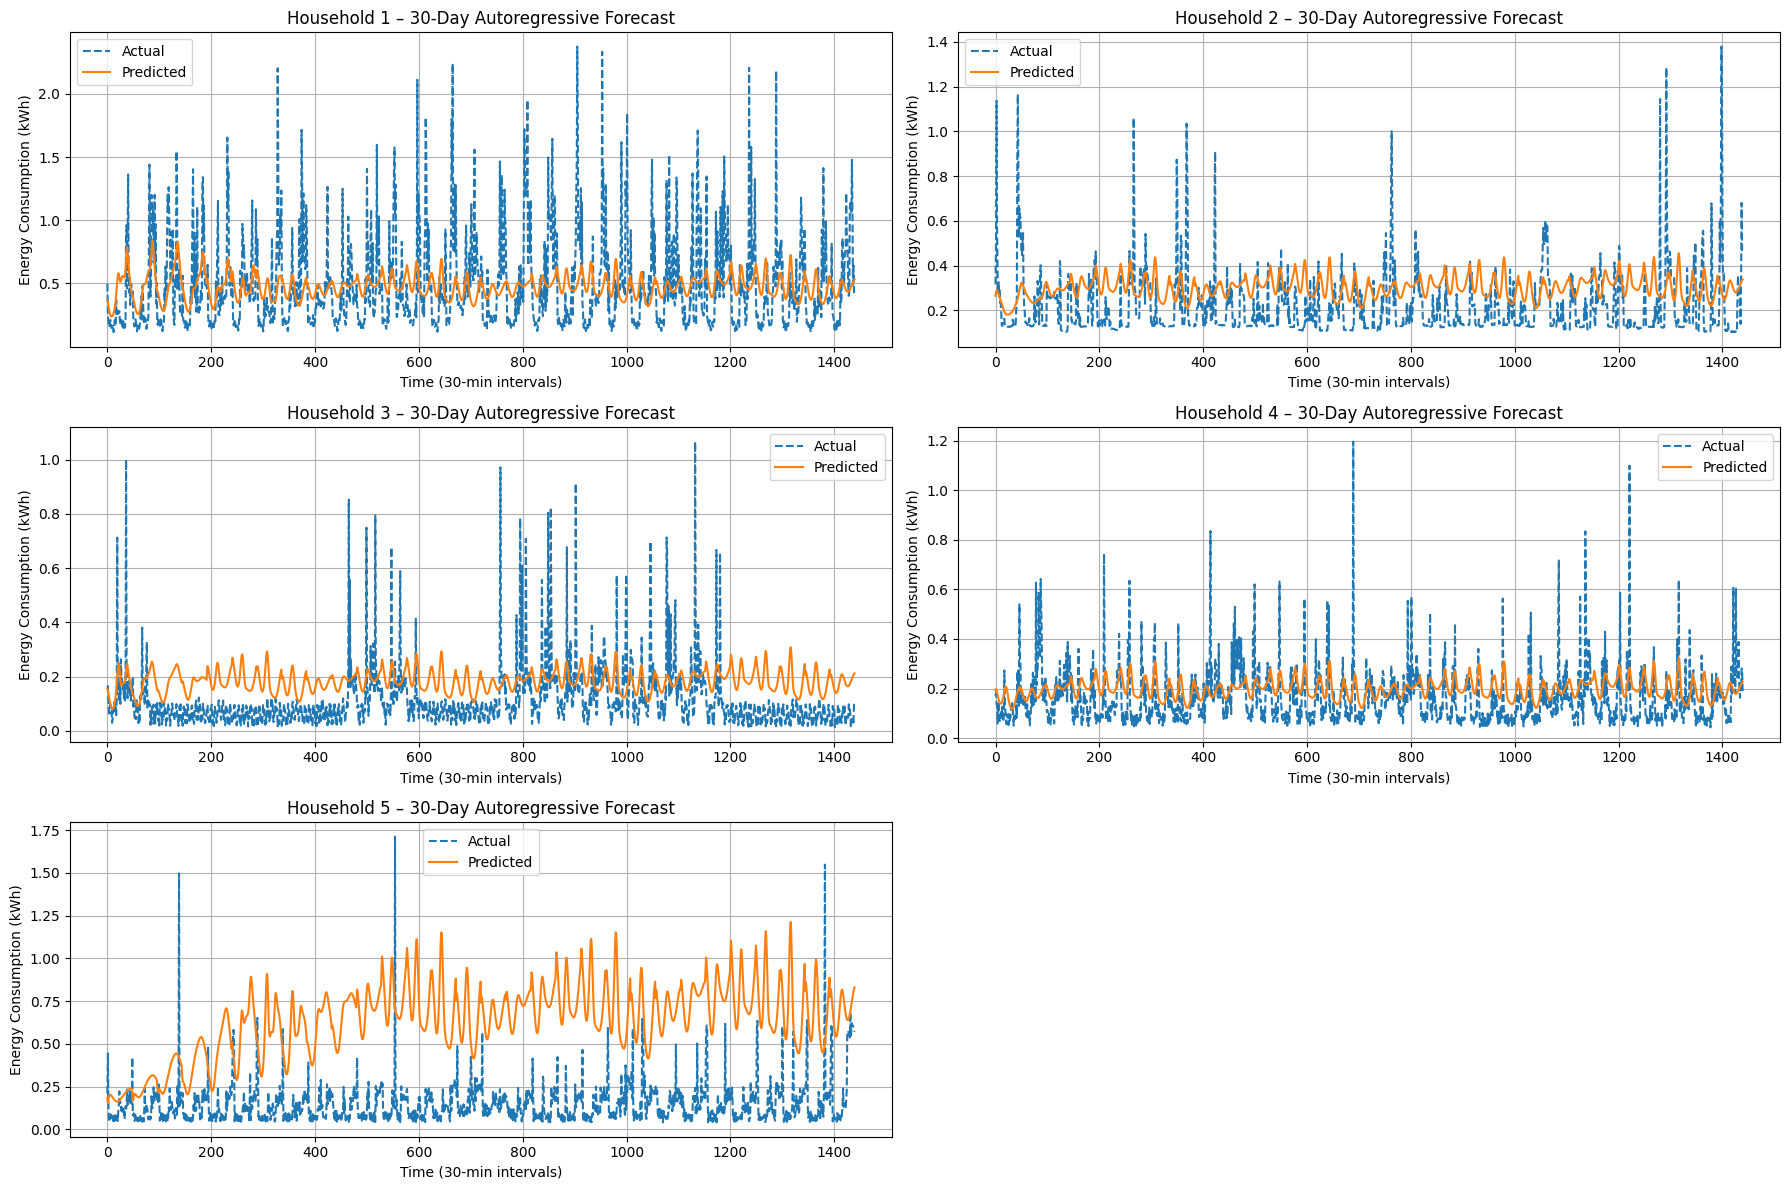

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(18, 12))

for h in range(len(rolling_preds)):
    plt.subplot(3, 2, h + 1)

    y_pred_plot = rolling_preds[h]
    y_true_plot = rolling_truths[h]

    x_axis = np.arange(len(y_true_plot))  # 1440 half-hours

    plt.plot(x_axis, y_true_plot, label='Actual', linestyle='--')
    plt.plot(x_axis, y_pred_plot, label='Predicted', linewidth=1.5)

    plt.title(f'Household {h+1} – 30-Day Autoregressive Forecast')
    plt.xlabel("Time (30-min intervals)")
    plt.ylabel("Energy Consumption (kWh)")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


# Unseen Household Testing

In [39]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

def rolling_day_forecast_autoregressive_unseen(series, time_feats, model, input_window=336, horizon=48, total_days=30):
    """
    Autoregressive daily forecast for a single unseen household.
    Predicts 48 steps per day, feeding predictions back into input.

    Args:
        series: 1D numpy array of energy usage (len >= input_window + total_days*horizon)
        time_feats: 2D numpy array of time features (same length as series)
        model: trained forecasting model
        input_window: history window size (default=336 half-hours = 7 days)
        horizon: number of steps per forecast (default=48 = 1 day)
        total_days: number of rolling forecast days (default=30)

    Returns:
        predictions: 1D numpy array of all forecasted values (total_days*horizon)
        actuals: 1D numpy array of corresponding actual values
    """
    # Scale household individually
    scaler_h = MinMaxScaler()
    series_scaled = scaler_h.fit_transform(series.reshape(-1, 1)).flatten()

    predictions = []

    # Initialize with first 7 days of actual data
    curr_input = series_scaled[:input_window].tolist()

    # Ground truth for evaluation
    true_values_full = series_scaled[input_window:input_window + total_days * horizon]

    for i in range(total_days):
        start_idx = i * horizon
        tf_input = time_feats[start_idx:start_idx + input_window]

        # Prepare combined input [energy, time features]
        input_combined = np.hstack([
            np.array(curr_input[-input_window:]).reshape(-1, 1),
            tf_input
        ])

        # Predict 48 steps for the next day
        pred = model.predict(input_combined[np.newaxis, :, :], verbose=0)  # shape (1, horizon, 1)
        pred_flat = pred.reshape(-1)  # shape (horizon,)

        # Append predictions to input sequence for autoregressive step
        curr_input.extend(pred_flat.tolist())

        # Store unscaled prediction
        pred_unscaled = scaler_h.inverse_transform(pred_flat.reshape(-1, 1)).flatten()
        predictions.append(pred_unscaled)

    # Return full predictions and actuals (both unscaled)
    actuals = scaler_h.inverse_transform(true_values_full.reshape(-1, 1)).flatten()
    return np.concatenate(predictions), actuals


In [41]:
from sklearn.metrics import mean_squared_error
import numpy as np

min_len_required = 336 + 30 * 48
valid_unseen = [col for col in energy_testing_set.columns if len(energy_testing_set[col]) >= min_len_required]

mse_list = []
house_ids = []

for col in valid_unseen:
    series = energy_testing_set[col].values
    tf_unseen = time_features[:len(series)]

    y_pred, y_true = rolling_day_forecast_autoregressive_unseen(series, tf_unseen, model)

    mse = mean_squared_error(y_true, y_pred)
    mse_list.append(mse)
    house_ids.append(col)

    print(f"Household {col}: MSE = {mse:.4f}")

print(f"\n Average Autoregressive MSE (Unseen Households): {np.mean(mse_list):.4f}")


Household uk_MAC003375: MSE = 0.0181
Household uk_MAC004019: MSE = 0.0348
Household uk_MAC003901: MSE = 0.0266
Household uk_MAC002320: MSE = 0.0597
Household uk_MAC002547: MSE = 0.0216
Household uk_MAC001857: MSE = 0.0230
Household uk_MAC003796: MSE = 0.1062
Household uk_MAC003081: MSE = 0.0373
Household uk_MAC000714: MSE = 0.0337
Household uk_MAC003958: MSE = 0.0671
Household uk_MAC001909: MSE = 0.0518
Household uk_MAC000855: MSE = 0.1770
Household uk_MAC001184: MSE = 0.0281
Household uk_MAC002168: MSE = 0.0067
Household uk_MAC005398: MSE = 1.0097
Household uk_MAC003237: MSE = 0.1987
Household uk_MAC005552: MSE = 0.0541
Household uk_MAC003981: MSE = 0.0882
Household uk_MAC001645: MSE = 0.0476
Household uk_MAC000281: MSE = 0.0204
Household uk_MAC000930: MSE = 0.0566
Household uk_MAC003535: MSE = 0.0476
Household uk_MAC004567: MSE = 0.0677
Household uk_MAC004016: MSE = 0.8204
Household uk_MAC005382: MSE = 0.1347
Household uk_MAC004100: MSE = 0.0064
Household uk_MAC004319: MSE = 1.0142
H